# Uinta Mountain Group ca. 759 Ma paleomagnetic pole

## Geologic context

The Uinta Mountain Group is a thick (4–7 km) succession of Tonian
(Neoproterozoic) quartzose to
arkosic sandstone and interbedded mudstone exposed
in the east–west Laramide Uinta uplift of northeast Utah, northwest Colorado, and
southwest Wyoming (Weil, Geissman & Ashby, 2006). It is interpreted to have accumulated in an
east–west-trending intracratonic rift basin and is one of the three **ChUMP**
(Chuar–Uinta Mountains–Pahrump) successions of southwestern Laurentia — regional
correlatives interpreted to record rift-basin evolution beginning ca. 770 Ma
during the incipient rifting of western Laurentia from Rodinia (Dehler et al.,
2023).

## Chronostratigraphy (Dehler et al., 2023)

Dehler et al. (2023) refined the Uinta Mountain Group depositional age with U-Pb chemical
abrasion–isotope dilution–thermal ionization mass spectrometry (CA-ID-TIMS) on
detrital zircon. The Uinta Mountain Group yields a maximum depositional age (MDA) of
766.3 ± 0.5 Ma (n = 5), with a second young detrital mode at 775.1 ± 0.7 Ma
(n = 3). Critically, the 766.3 Ma grains occur ~60 m above the base of the eastern
UMG (basal Jesse Ewing Canyon Formation), which requires that the UMG is
younger than 766 Ma — a refinement of earlier SHRIMP/LA-ICP-MS
maximum ages (e.g. 766.4 ± 4.8 Ma from the Outlaw Trail formation; Dehler et al.,
2010).

The Red Pine Formation of the Uinta Mountain Group is correlated with Kwagunt Formation of the Chuar Group (which both have vase-shape microfossils). Given that all Uinta Mountain Group paleomagnetic sites are below the Red Pine Formation we can consider the younger age bound as the date of 751.0 ± 7.6 Ma (from Rooney et al. 2018) from the lower Kwagunt.

## Pole

This notebook recreates the UMG characteristic-remanence pole at the site level
from the 9 sampling localities (79 sites) of Weil et al. (2006). The ChRM
is a west- or east-directed (dual-polarity), shallow, hematite-carried
magnetization; the four eastern localities that yielded only a north-directed
present-field viscous overprint are shown separately.

## References
- Dehler, C., Schmitz, M., Bullard, A., Porter, S., Timmons, M., Karlstrom, K., & Cothren, H. (2023). Precise U-Pb age models refine Neoproterozoic western Laurentian rift initiation, correlation, and Earth system changes. *Precambrian Research*, 396, 107156. https://doi.org/10.1016/j.precamres.2023.107156
- Dehler, C. M., Fanning, C. M., Link, P. K., Kingsbury, E. M., & Rybczynski, D. (2010). Maximum depositional age and provenance of the Uinta Mountain Group and Big Cottonwood Formation, northern Utah: Paleogeography of rifting western Laurentia. *GSA Bulletin*, 122(9–10), 1686–1699. https://doi.org/10.1130/B30094.1
- Rooney, A. D., Austermann, J., Smith, E. F., Li, Y., Selby, D., Dehler, C. M., Schmitz, M. D., Karlstrom, K. E., & Macdonald, F. A. (2018). Coupled Re-Os and U-Pb geochronology of the Tonian Chuar Group, Grand Canyon. *GSA Bulletin*, 130(7–8), 1085–1098. https://doi.org/10.1130/B31768.1
- Weil, A. B., Geissman, J. W., & Ashby, J. M. (2006). A new paleomagnetic pole for the Neoproterozoic Uinta Mountain supergroup, Central Rocky Mountain States, USA. *Precambrian Research*, 147(3–4), 234–259. https://doi.org/10.1016/j.precamres.2006.01.017

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Locality poles and the UMG mean

The locations table holds a VGP (locality pole) for each sampling locality. The
UMG pole is the Fisher mean of the 9 primary-ChRM locality VGPs; the four
present-field overprint localities (Irish Canyon, Cross Mountain, Lone Mountain,
Juniper Mountain) are excluded.

9 primary localities
Plon: 161.3  Plat: 0.8
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 4.6
Precision parameter (k) estimate: 125.6

Weil et al. (2006) UMG pole: 0.8 N / 161.3 E, A95 4.6, N=9


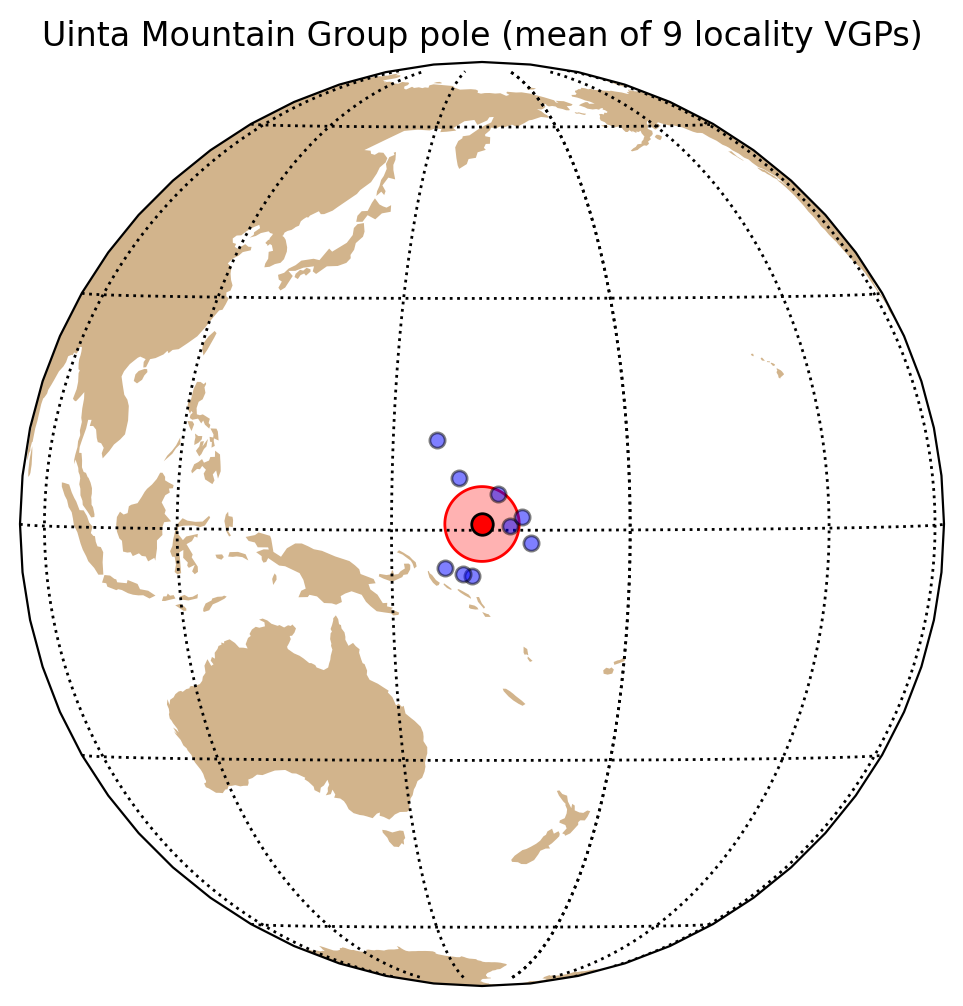

In [2]:
locs = pd.read_csv('../data/759_Uinta_Mountain_Group/locations.txt', sep='\t', skiprows=1)
overprint = ['Irish Canyon Section', 'Cross Mountain', 'Lone Mountain', 'Juniper Mountain']
primary = locs[(~locs['location'].isin(overprint)) &
               (~locs['location'].str.contains('Uinta Mountain Group ca', na=False))].copy()
study_lat, study_lon = 40.8, 250.7

# treat each locality VGP as one site for the grand-mean pole
loc_sites = pd.DataFrame({'site': primary['location'], 'vgp_lat': primary['pole_lat'],
                          'vgp_lon': primary['pole_lon'], 'dir_tilt_correction': 100,
                          'dir_n_samples': primary['pole_n_sites'].fillna(1).astype(int)})
print(f'{len(loc_sites)} primary localities')
vgp_block, pole_mean = pt.compute_mean_pole(loc_sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nWeil et al. (2006) UMG pole: 0.8 N / 161.3 E, A95 4.6, N=9')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Uinta Mountain Group pole (mean of 9 locality VGPs)')
plt.show()

### Site mean pole

For comparison, the pole is also computed as the Fisher mean of the individual
ChRM site VGPs rather than the locality means. Each site VGP is recomputed from
the site's tilt-corrected direction and coordinates with `pmag.dia_vgp` (the
contribution's VGP columns store the locality mean, so per-site VGPs are
recomputed here). The locality mean weights each of the 9 localities equally,
whereas the site mean weights by site count; close agreement indicates the pole
is not sensitive to the averaging level.

Site mean pole     (N=74 ChRM sites): 1.9 N / 160.6 E, A95 2.1, K 61.5
Locality mean pole (N=9 localities): 0.8 N / 161.3 E, A95 4.6, K 125.6


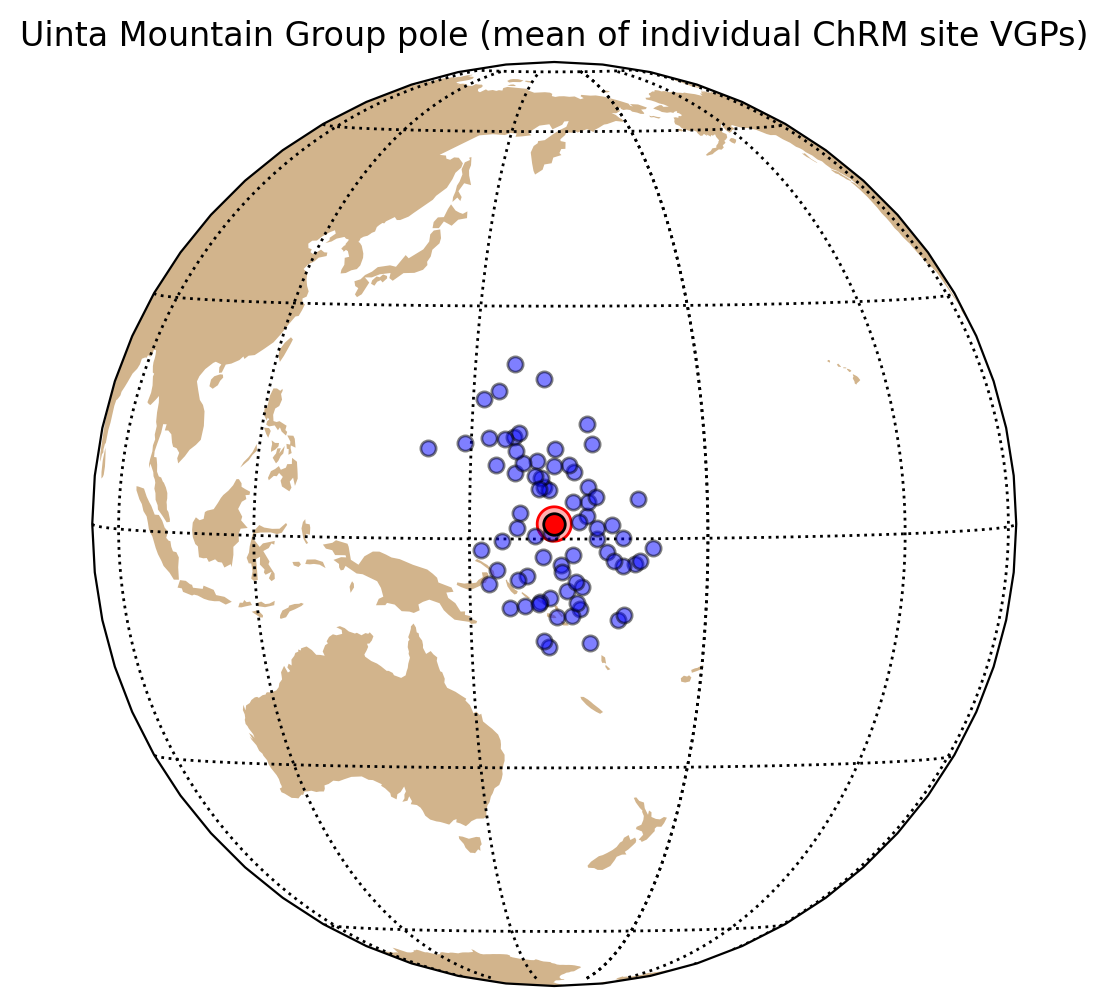

In [3]:
sites_all = pd.read_csv('../data/759_Uinta_Mountain_Group/sites.txt', sep='\t', skiprows=1)
chrm = sites_all[(sites_all['dir_comp_name'] == 'ChRM') &
                 (sites_all['dir_tilt_correction'] == 100) &
                 (sites_all['result_quality'] == 'g') &
                 (~sites_all['location'].isin(overprint))].copy()
# per-site VGPs from each site's direction and coordinates
plon, plat = [], []
for _, r in chrm.iterrows():
    a = r['dir_alpha95'] if pd.notna(r['dir_alpha95']) else 5.0
    vlon, vlat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], a, r['lat'], r['lon'])
    plon.append(vlon); plat.append(vlat)
chrm = chrm.assign(vgp_lon=plon, vgp_lat=plat)

site_block, site_pole = pt.compute_mean_pole(chrm, unify_polarity=True)
print(f"Site mean pole     (N={int(site_pole['n'])} ChRM sites): "
      f"{site_pole['inc']:.1f} N / {site_pole['dec']:.1f} E, A95 {site_pole['alpha95']:.1f}, K {site_pole['k']:.1f}")
print(f"Locality mean pole (N={int(pole_mean['n'])} localities): "
      f"{pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}, K {pole_mean['k']:.1f}")

_ = pt.plot_vgps_and_pole(site_block, site_pole, central_longitude=site_pole['dec'],
                          central_latitude=site_pole['inc'], figsize=(6, 6))
plt.title('Uinta Mountain Group pole (mean of individual ChRM site VGPs)')
plt.show()

### Reversal test (site directions)

The dual-polarity ChRM (west-directed normal, east-directed reversed) is tested
with the McFadden & McElhinny (1990) and bootstrap reversal tests applied to the
individual tilt-corrected site directions, split by their principal eigenvector
without prior polarity unification.

74 directions (polarity 1: 36, polarity 2: 38)

McFadden & McElhinny (1990) reversal test
------------------------------------------


Results of Watson V test: 

Watson's V:           26.9
Critical value of V:  6.2
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 11.2
Critical angle for M&M1990:   5.4


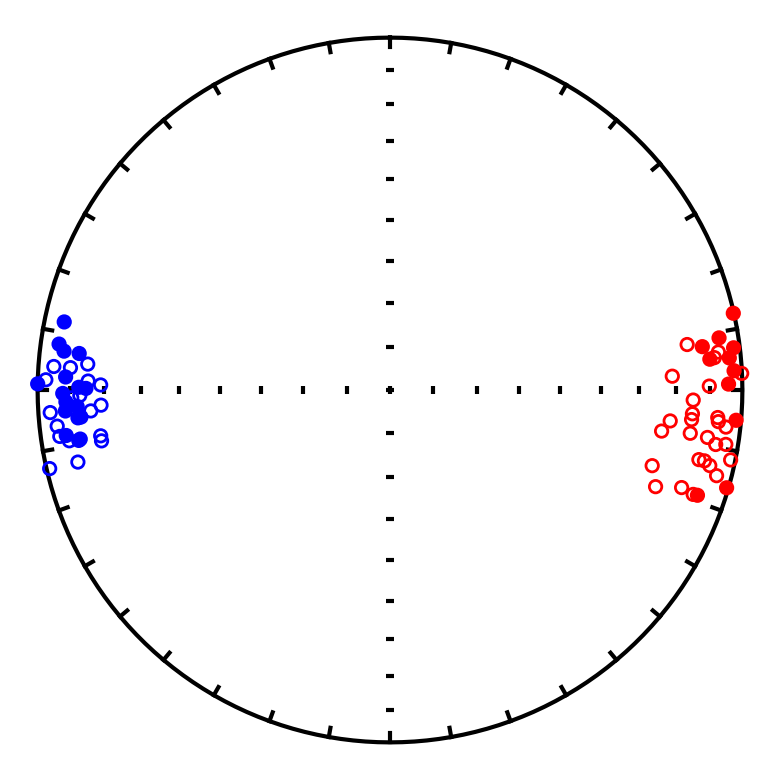


Bootstrap reversal test
------------------------------------------


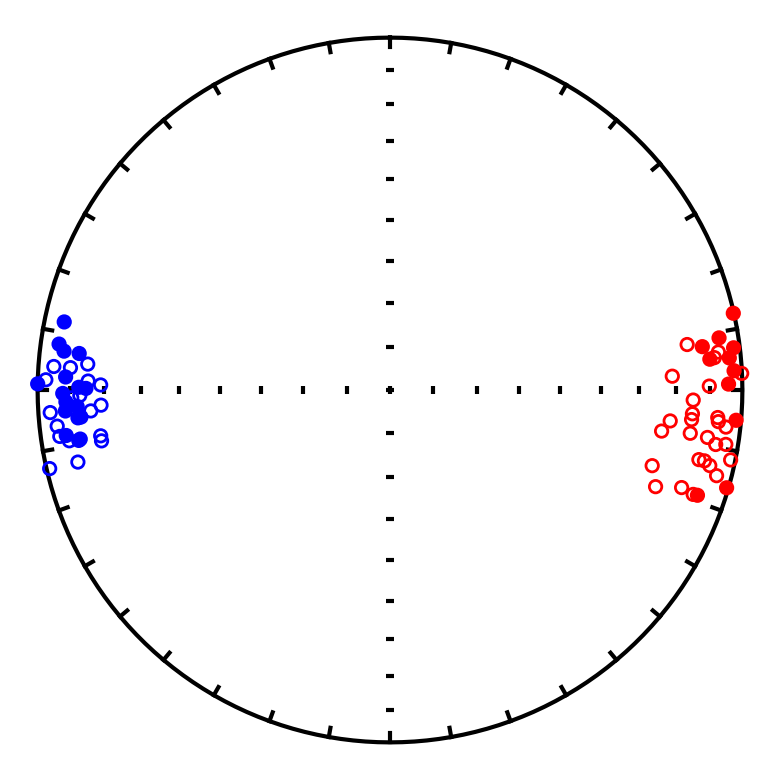

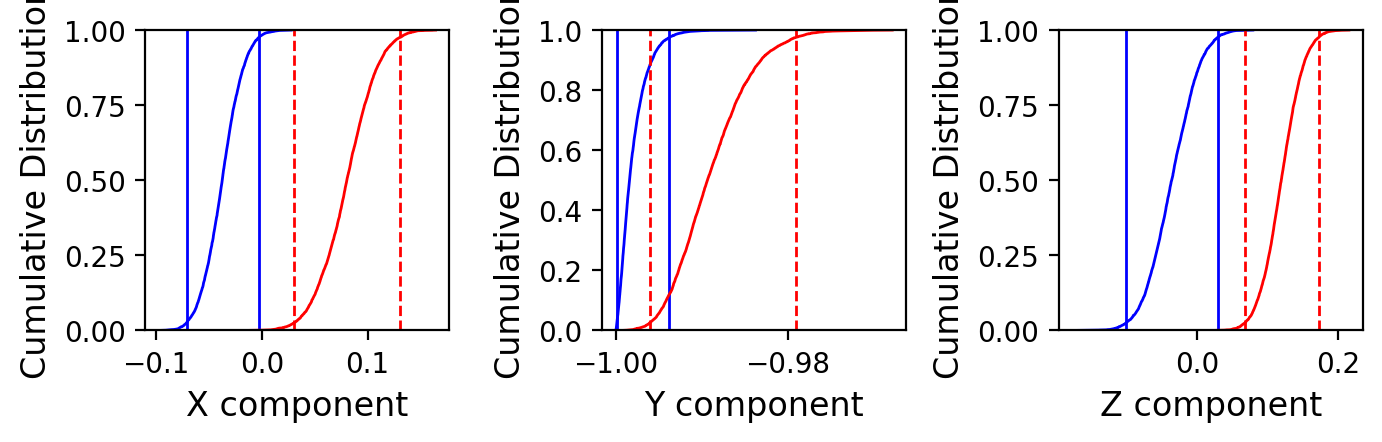

Fail, distinct in x and z


In [4]:
_ = pt.reversal_test(chrm, plot=True, random_seed=1)

### Fold test

The Uinta Mountain Group is deformed by the Laramide Uinta arch, so a fold test
bears on whether the ChRM predates folding. The bootstrap fold test of Tauxe &
Watson (1994) is applied to the in-situ (geographic) ChRM site directions using
each site's bedding (`bed_dip`, `bed_dip_direction`). Note that Weil et al. (2006)
document substantial, spatially variable vertical-axis rotations across the arch;
because a coaxial unfolding does not remove vertical-axis rotation, the optimum
percent-unfolding here need not reach 100% even for a pre-folding remanence.

The bootstrap fold test (Tauxe & Watson, 1994) on the 74 in-situ ChRM site
directions finds the tightest grouping at 46–76% unfolding (95% confidence
bounds; full range 36–83%) — an intermediate optimum that does not bracket 100%
and so is not a statistically positive fold test.

Weil et al. (2006) likewise found the fold test inconclusive. Their two local
tests gave opposite tendencies: at the Dowd Springs upright anticline grouping
improved on tilt correction (k 19.8 → 34.9) but below the 90% significance
threshold, whereas at the Sheep Creek Canyon fold dispersion increased
significantly on untilting. They emphasized that both tests have little resolving
power because the bedding strikes are roughly E–W, sub-parallel to the
E–W-directed ChRM, so unfolding reorients the magnetization vectors very little.
They instead inferred a primary, pre-folding ChRM from the contrasting
north-directed overprint — whose grouping degrades sharply on untilting
(k 36 → 11), marking it a clearly post-tilting (Laramide) magnetization — together
with the dual-polarity ChRM and the pole's agreement with other Neoproterozoic
Laurentia poles. The intermediate optimum found here is consistent with this
geometric insensitivity rather than with a synfolding remanence.

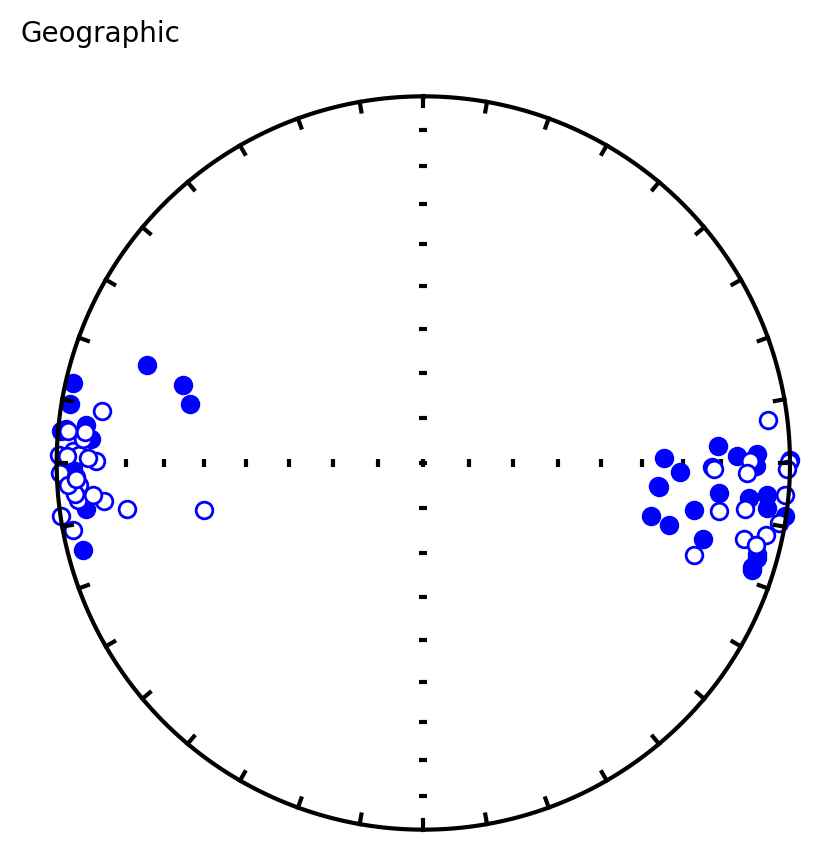

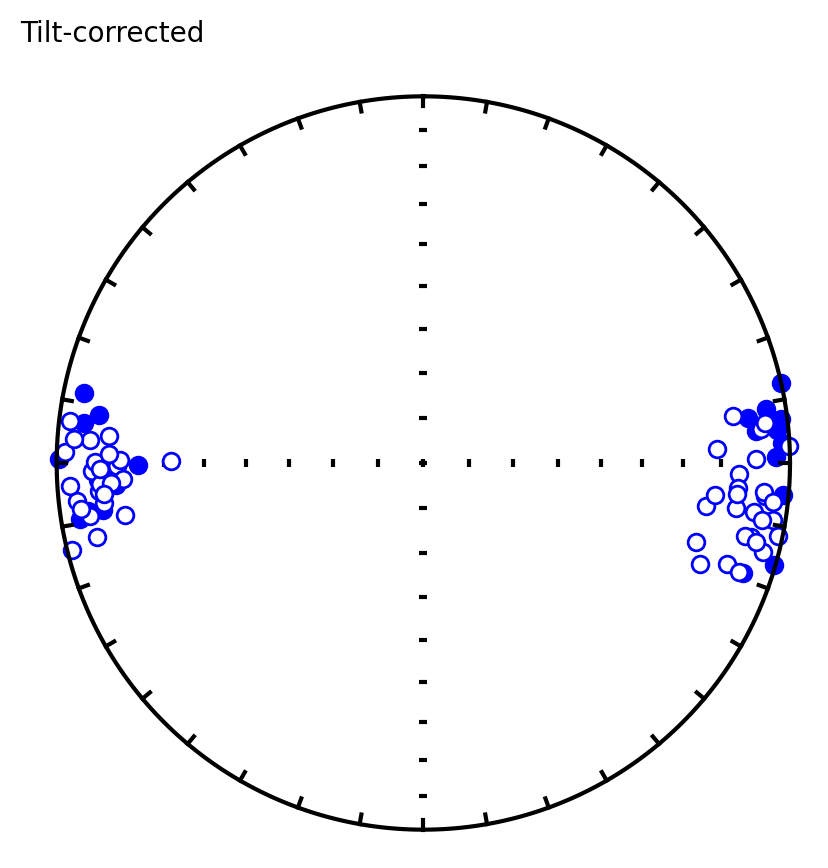

doing  1000  iterations...please be patient.....



tightest grouping of vectors obtained at (95% confidence bounds):
46 - 76 percent unfolding
range of all bootstrap samples: 
36  -  83 percent unfolding


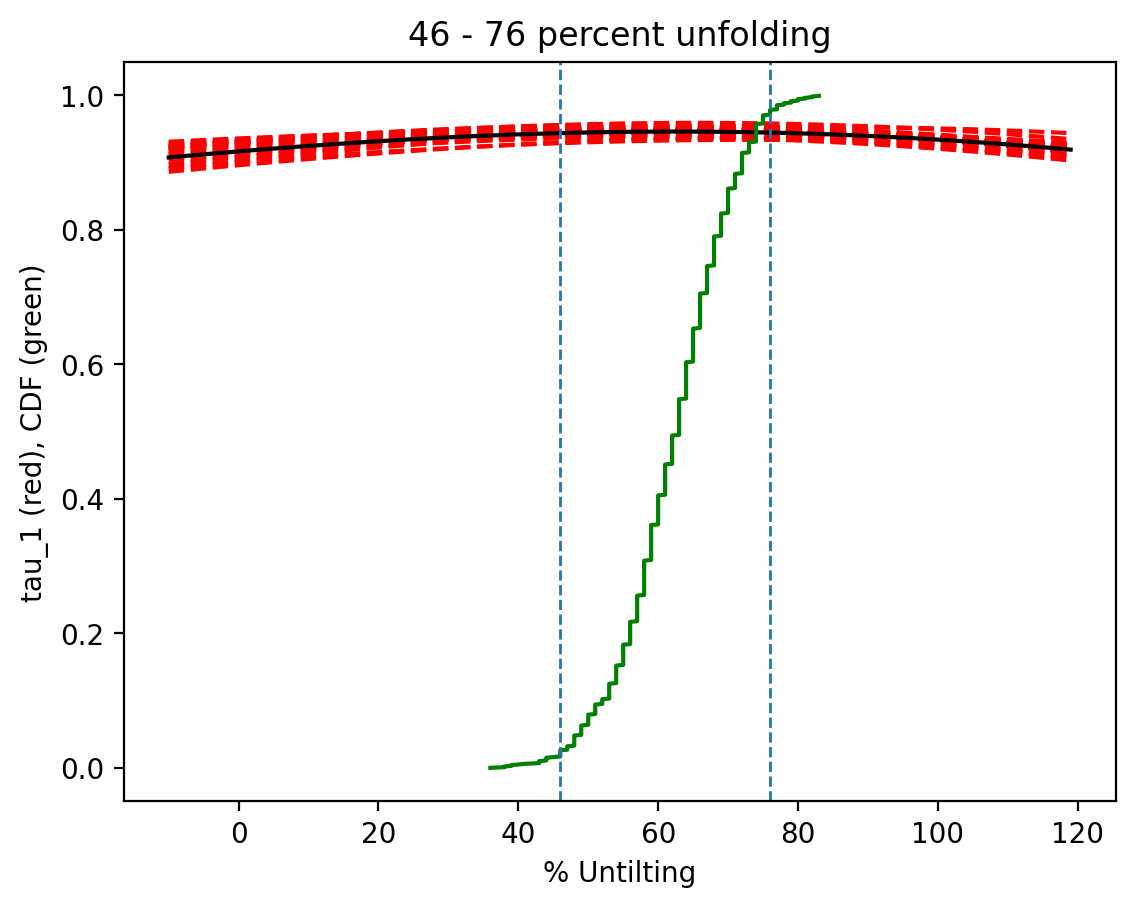

In [5]:
# bootstrap fold test (Tauxe & Watson, 1994) on the in-situ ChRM site directions,
# using each site's bedding (bed_dip_direction, bed_dip)
chrm_insitu = sites_all[(sites_all['dir_comp_name'] == 'ChRM') &
                        (sites_all['dir_tilt_correction'] == 0) &
                        (sites_all['result_quality'] == 'g') &
                        (~sites_all['location'].isin(overprint))].copy()
fold_data = chrm_insitu[['dir_dec', 'dir_inc', 'bed_dip_direction', 'bed_dip']].values
ipmag.bootstrap_fold_test(fold_data, num_sims=1000, random_seed=23)

## Present-field overprint localities (context)

The four eastern localities carry a north-directed, steep, present-field viscous
remanence — their VGPs plot near the present pole, not with the UMG ChRM.

In [6]:
op = locs[locs['location'].isin(overprint)]
print(op[['location', 'pole_lat', 'pole_lon', 'pole_alpha95', 'pole_n_sites']].to_string(index=False))

            location  pole_lat  pole_lon  pole_alpha95  pole_n_sites
Irish Canyon Section      79.7     322.2           5.6            22
      Cross Mountain      83.9     177.8           6.9            22
       Lone Mountain      88.2     203.6           7.0            22
    Juniper Mountain      88.2     203.6          12.9            64


## Paleosecular variation

The dual-polarity ChRM (west-normal / east-reverse) and the spread of locality
VGPs indicate the magnetization averaged secular variation; the Deenen et al.
(2011) test is applied to the 9-locality mean.

A_95 of 2.1 is too small for Deenen criteria of 2.1 for this number of sites


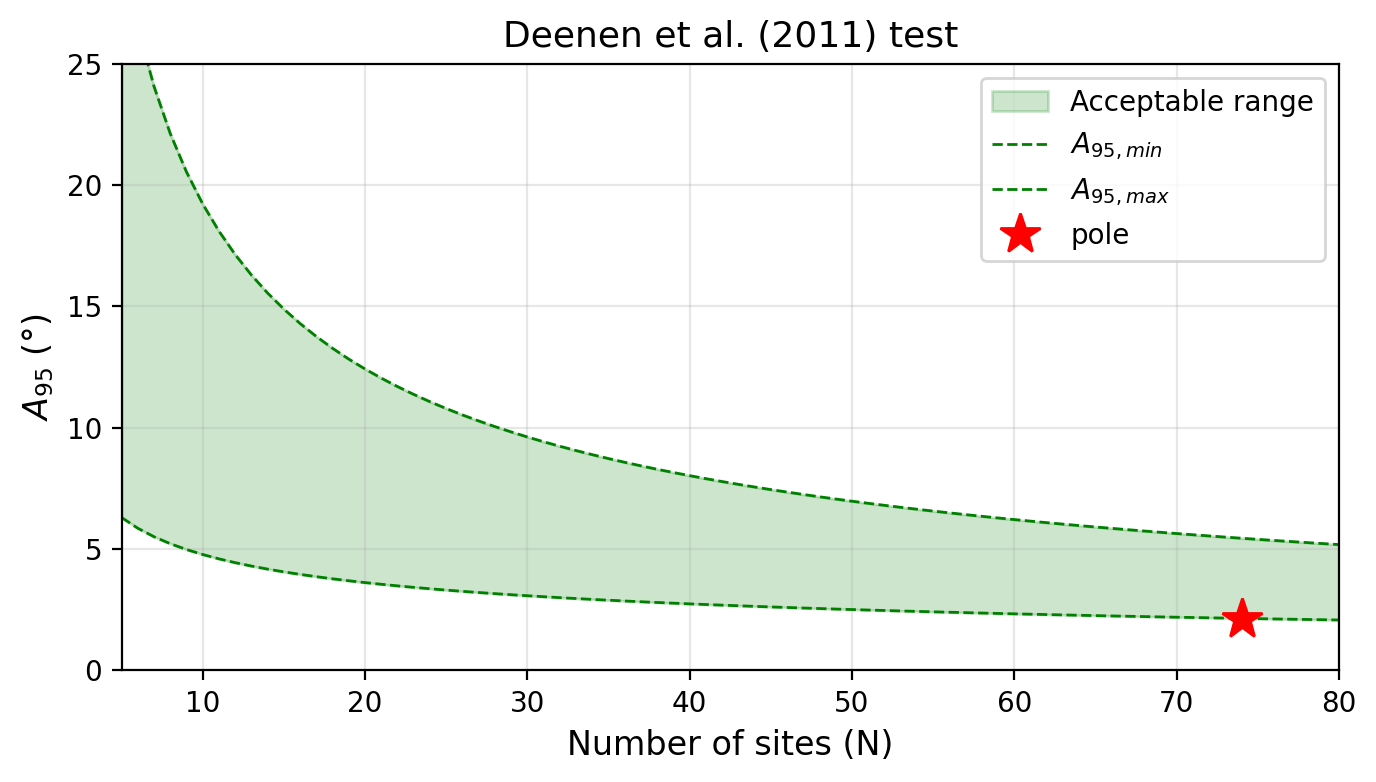

In [7]:
pt.Deenen_test(site_pole['n'], site_pole['alpha95'])
_ = pt.plot_Deenen_test(site_pole)

A_95 of 4.6 is too small for Deenen criteria of 5.0 for this number of sites


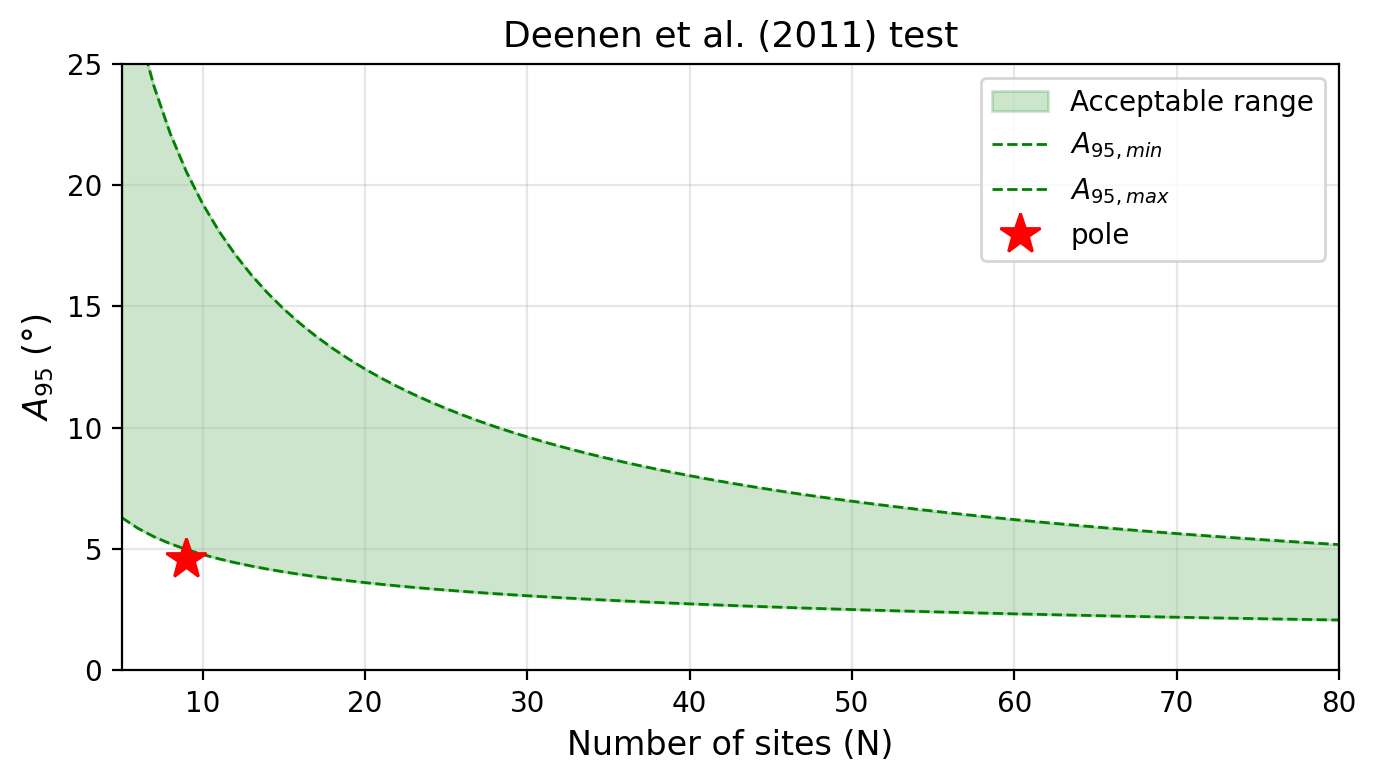

In [8]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
_ = pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(160.5933027182828),
 'Inc': np.float64(1.8370053125838293),
 'N': 74,
 'Mu': np.float64(1.4068702274667886),
 'Mu_critical': 1.207,
 'Me': np.float64(0.9677522065316284),
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

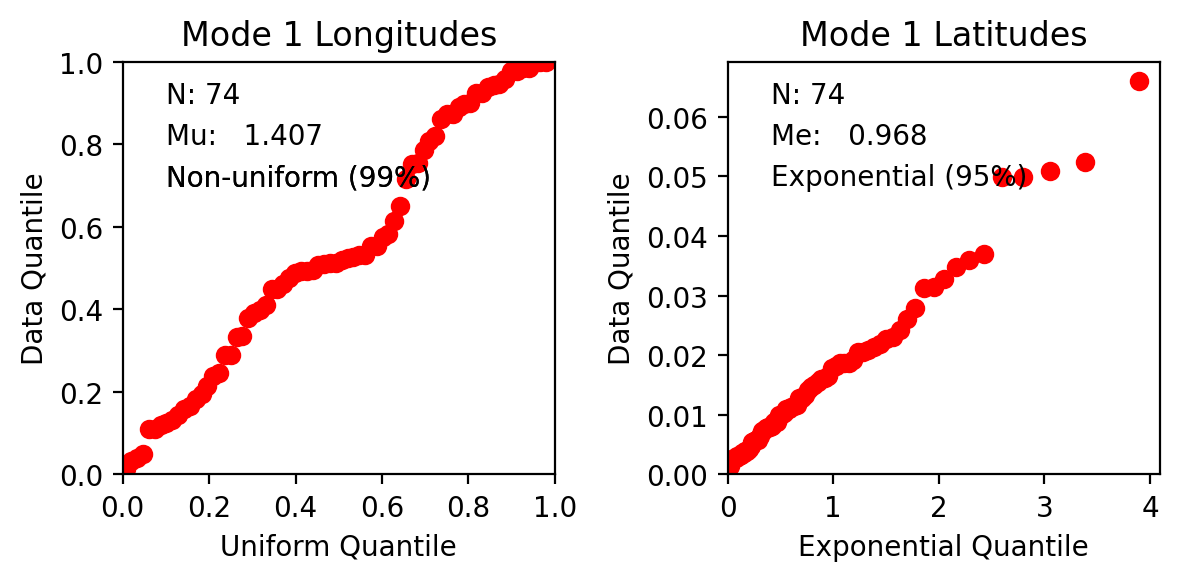

In [9]:
fishqq_result = pt.fishqq_vgps(chrm, unify_polarity=True)
fishqq_result

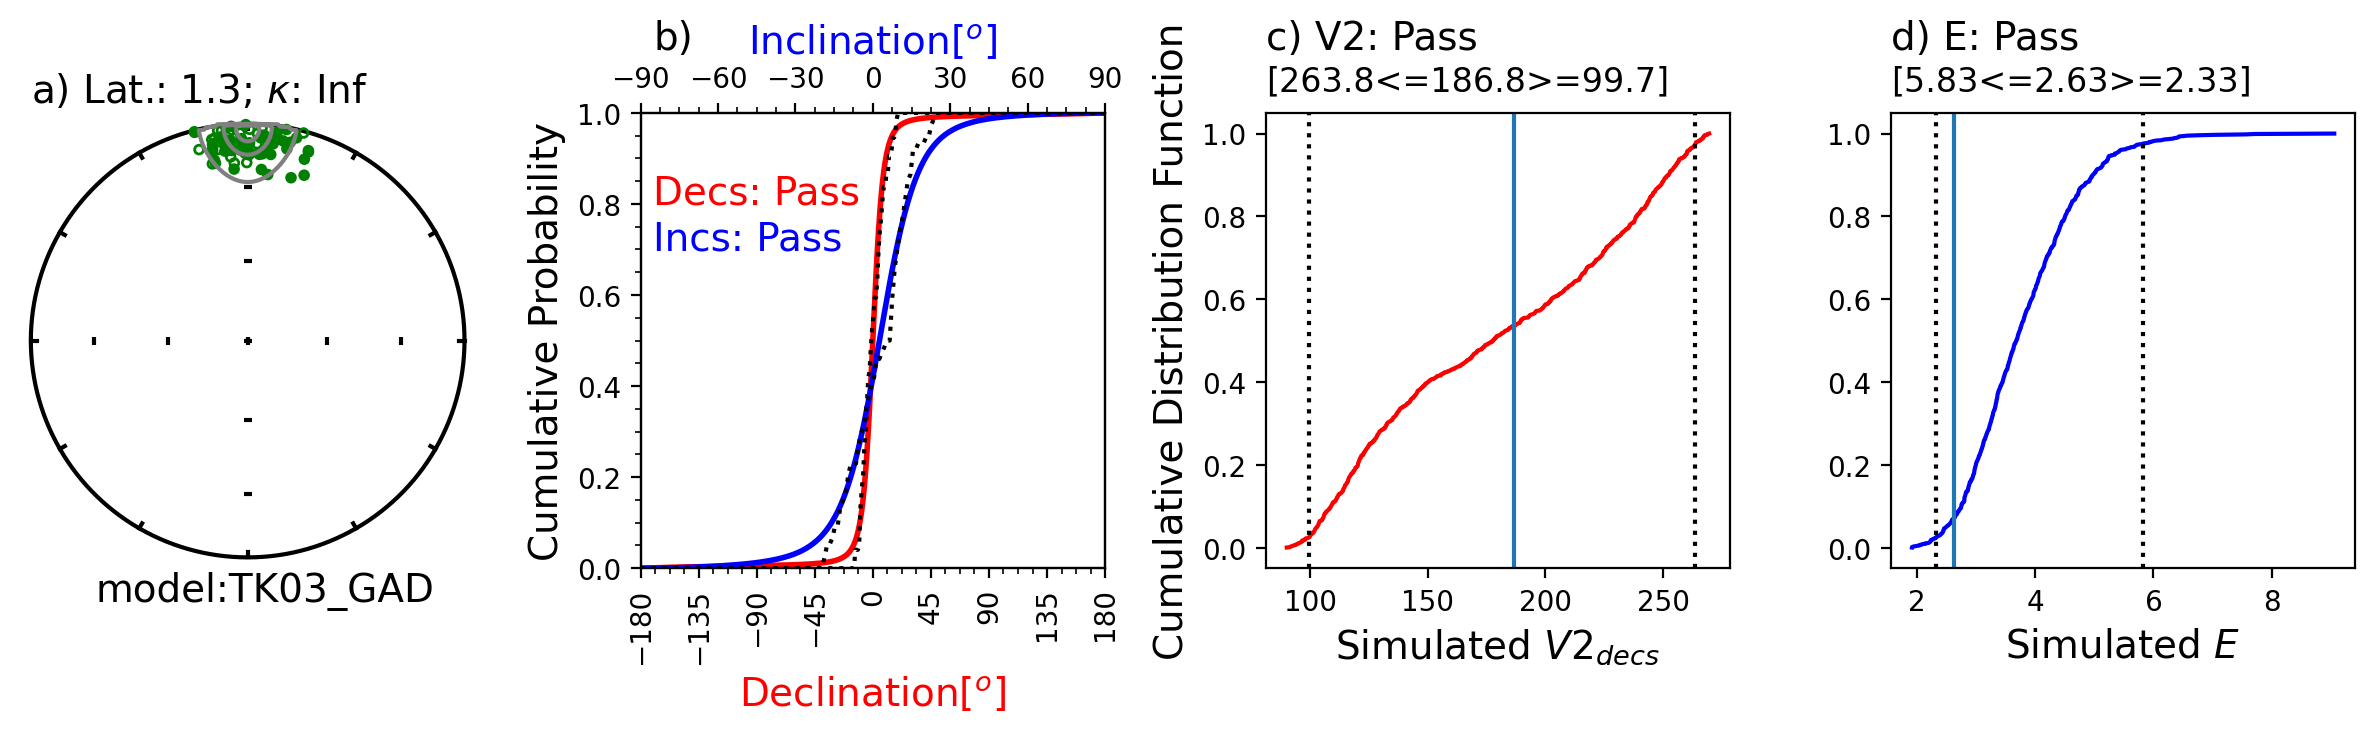

paleolatitude = 1.3 deg; elongation E = 2.63 (consistent with TK03.GAD)


In [10]:
_slat, _slon = float(chrm['lat'].mean()), float(chrm['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(chrm, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(chrm, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The UMG pole in the context of the Laurentia APWP

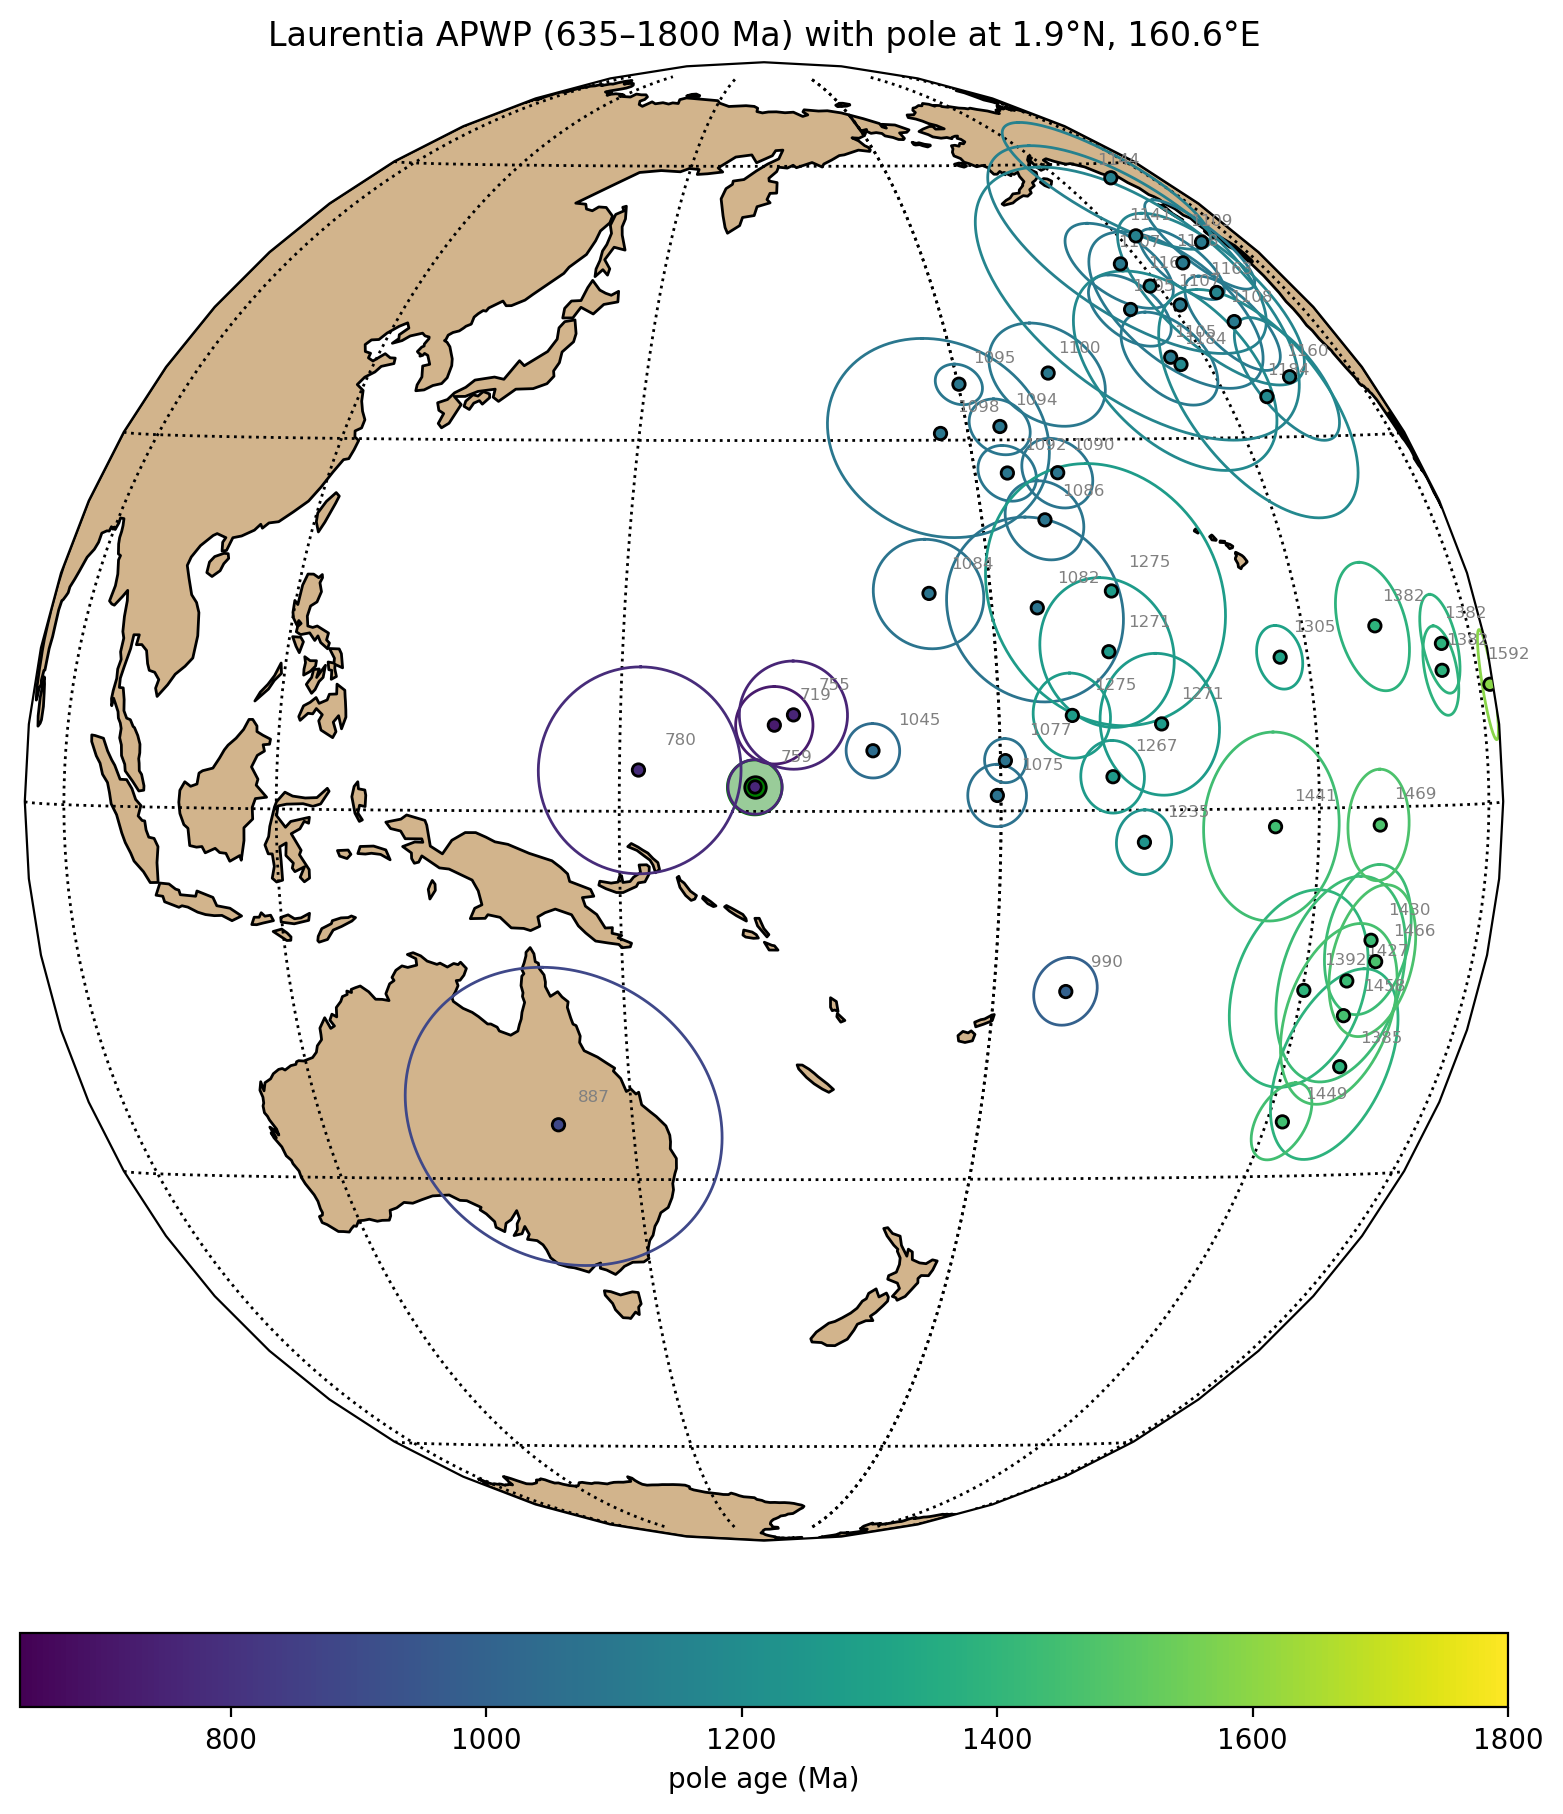

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, site_pole['inc'], site_pole['dec'],
                          site_pole['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

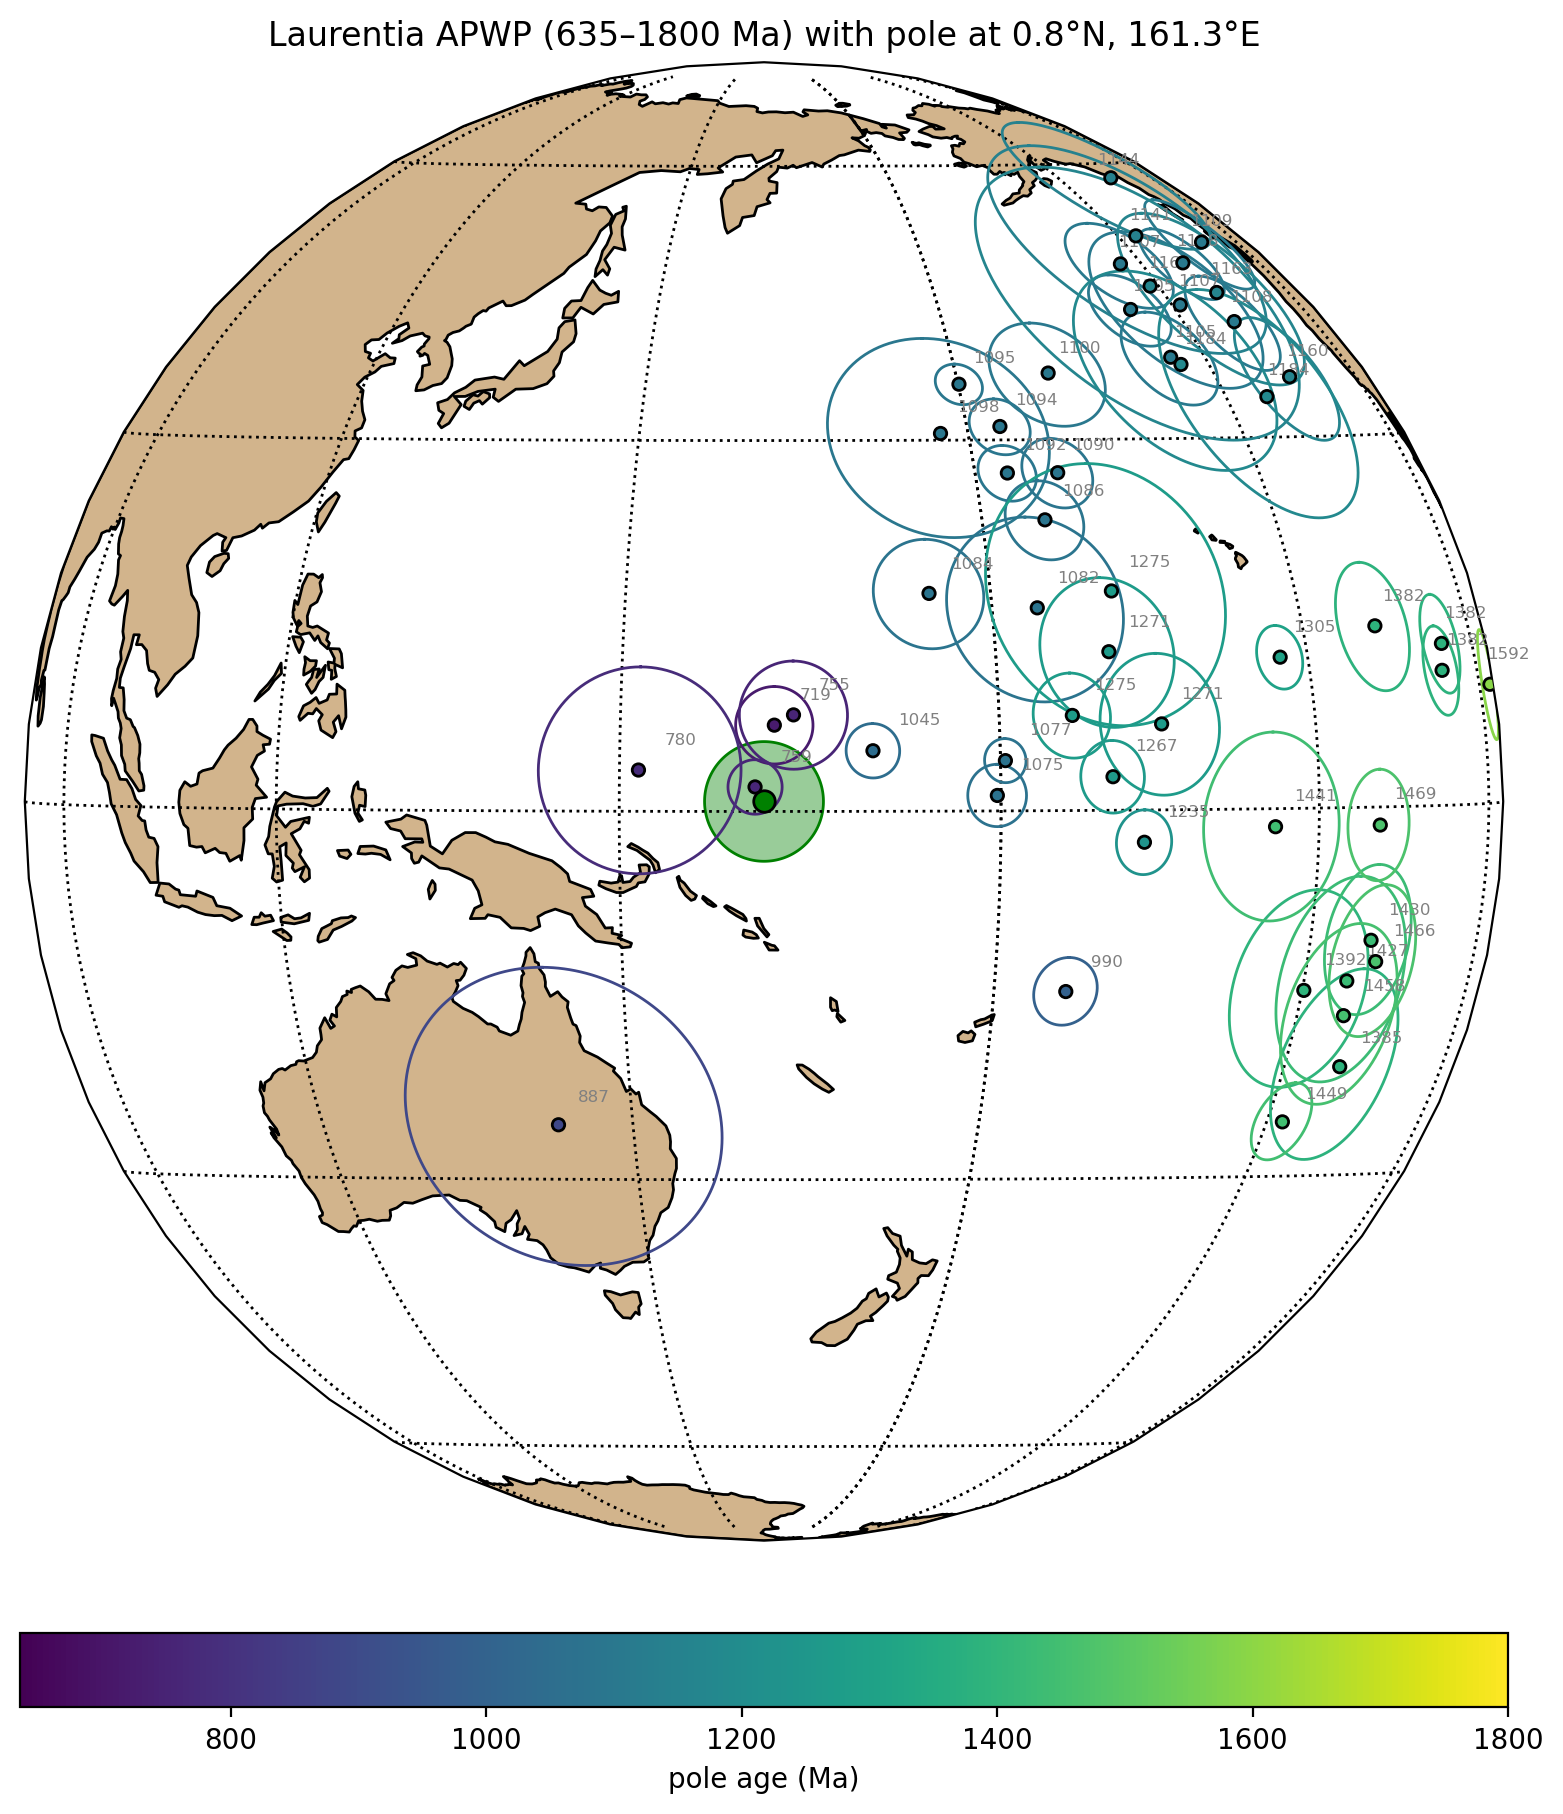

In [12]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

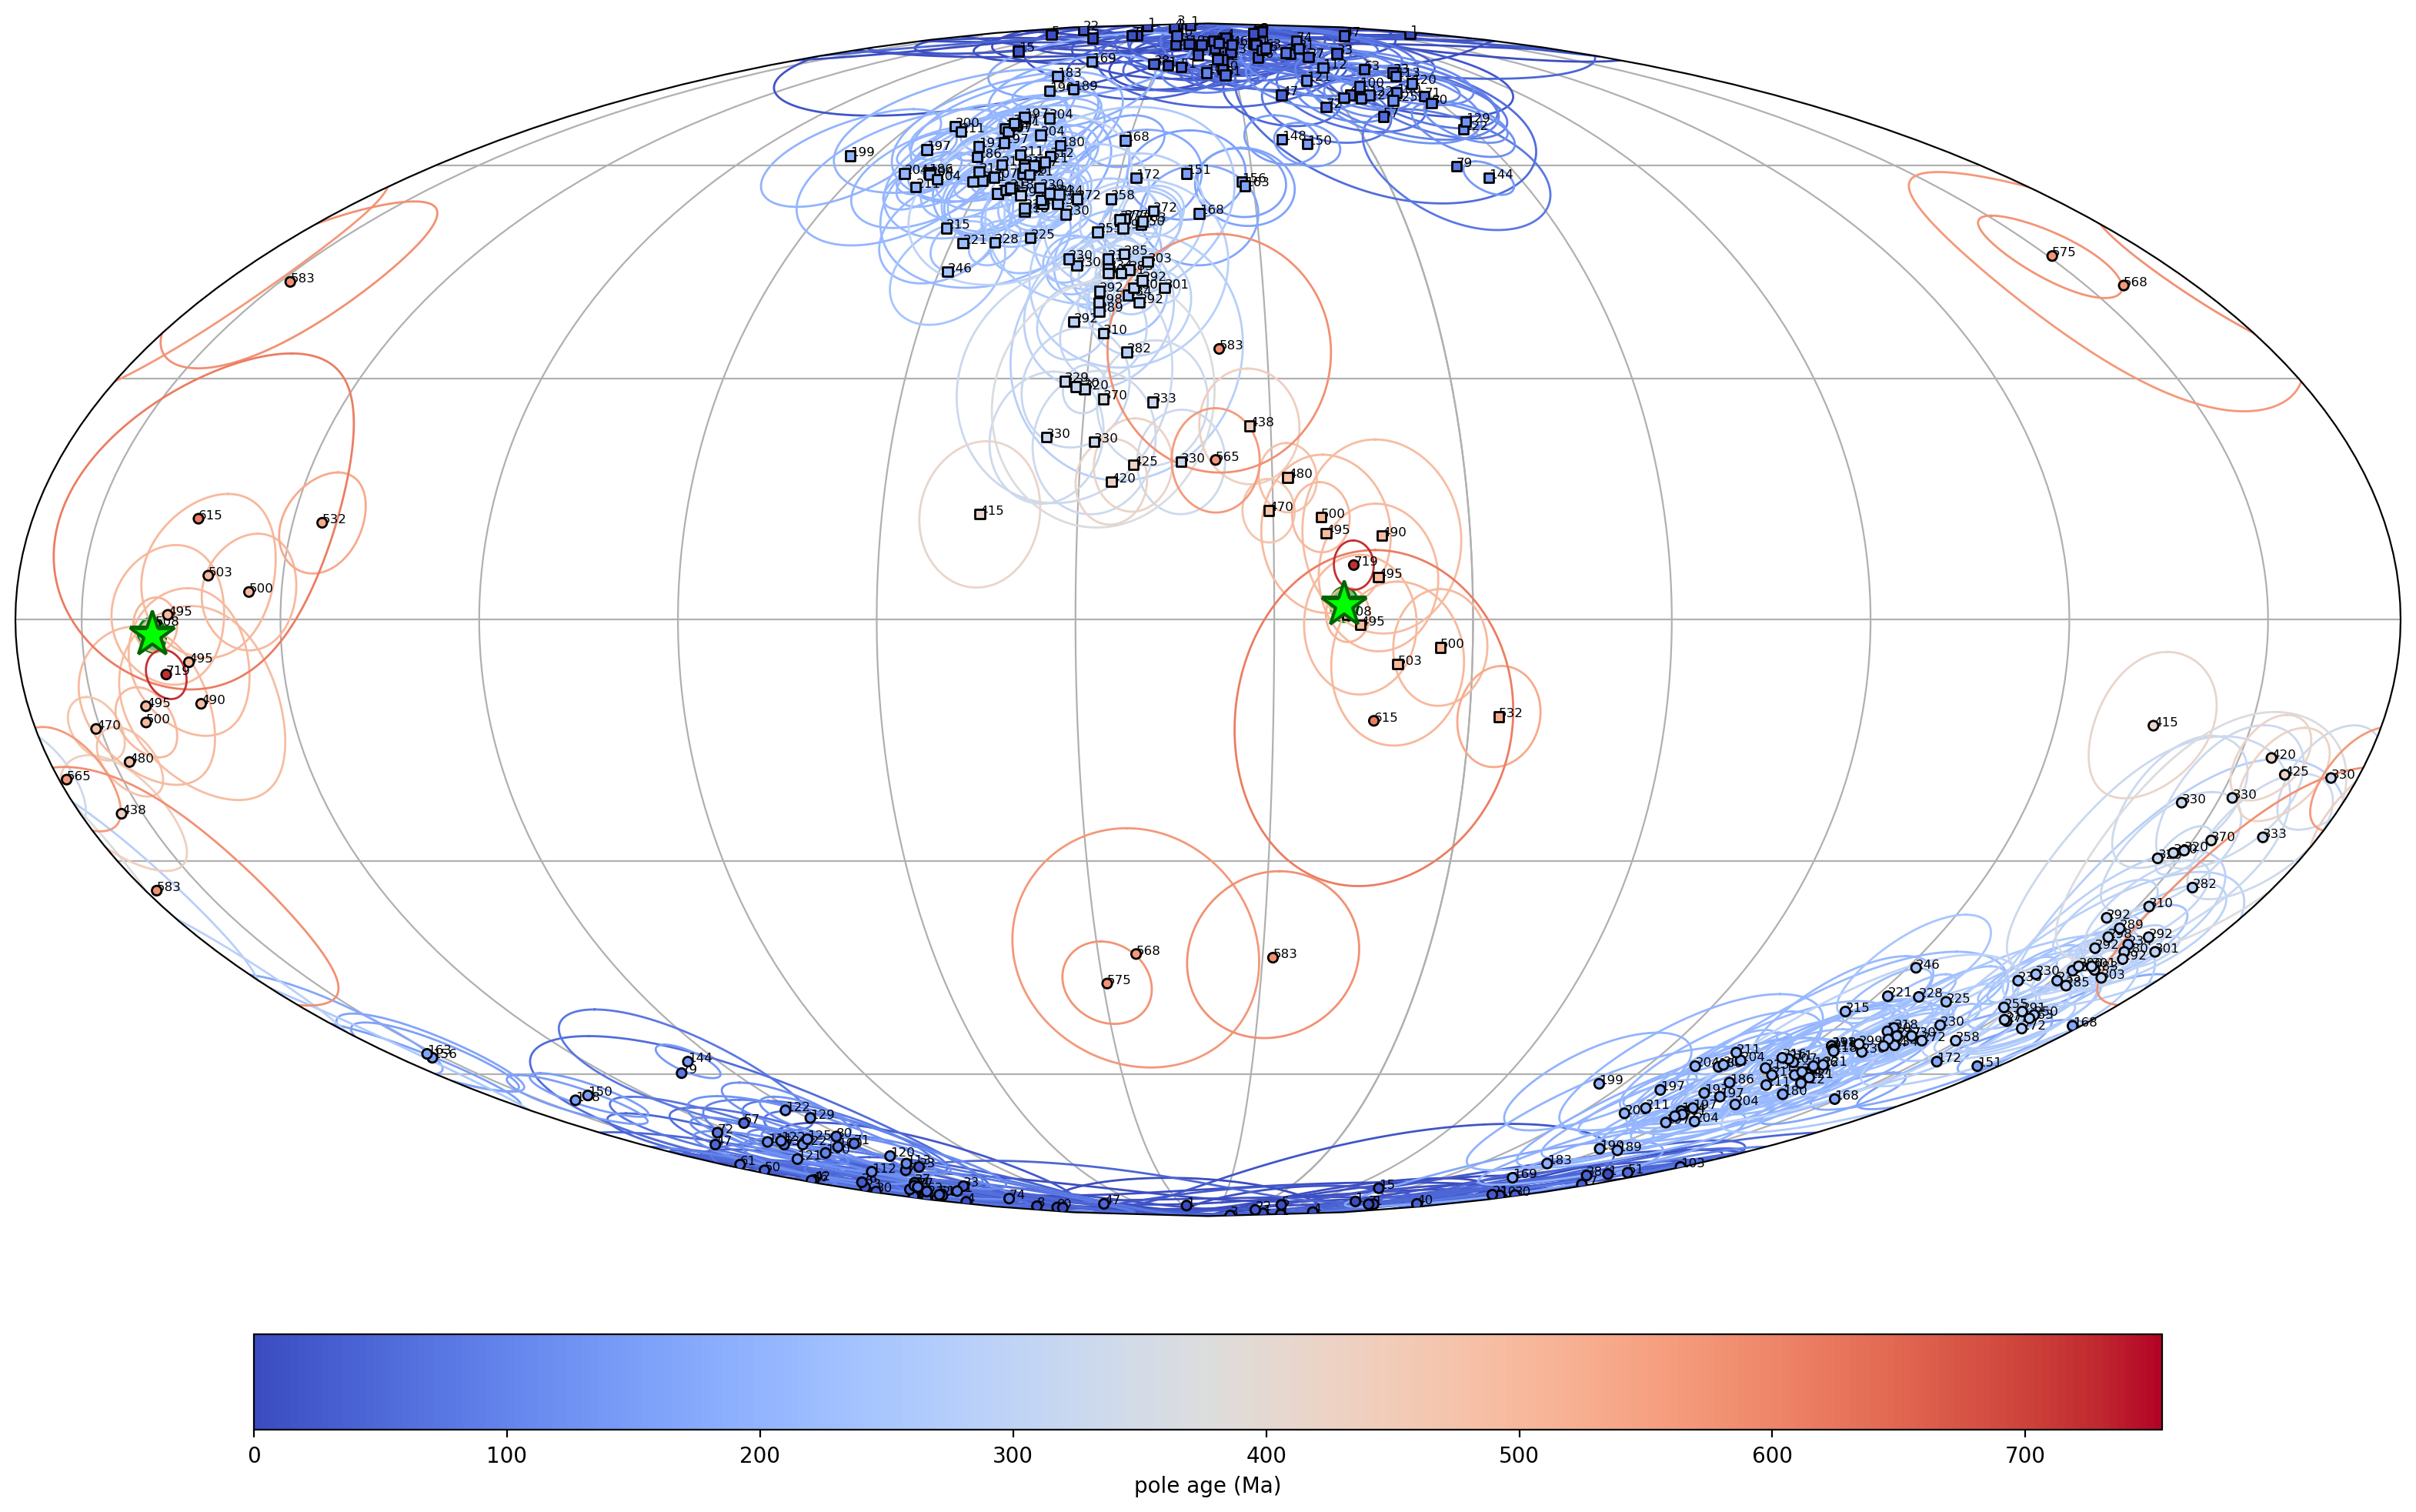

In [13]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Uinta Mountain Group', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=site_pole['inc'], pole_plon=site_pole['dec'],
                     pole_A95=site_pole['alpha95'], pole_age=754)
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | A maximum-depositional-age bracket and dated correlation to Kwagunt Fm of Chuar Group constrains between 766.3 ± 0.5 Ma (Dehler et al., 2023) and 751.0 ± 7.6 Ma (Rooney et al., 2018). |
| 2 | Techniques and statistical analysis | **1** | Thermal + chemical demagnetization, PCA, IRM mineralogy; N = 9 localities (79 sites); the dual-polarity ChRM averages secular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by hematite, characterized by high unblocking temperatures (660-680 °C) and three-axis IRM (Weil et al., 2006). |
| 4 | Field tests constrain age of magnetization | **0** | Fold tests were local/inconclusive; no decisive regional field test. |
| 5 | Structural control / tectonic coherence | **1** | Laramide uplift that is part of Laurentia. Inclination shallowing will have minimal effect due to low inclinations of both polarities. |
| 6 | Presence of reversals | **0** | Dual polarity is present (west-normal / east-reverse ChRM), but a McFadden & McElhinny (1990) reversal test on the site directions is negative — the normal and reversed means differ by ~11°. |
| 7 | No resemblance to younger poles | **0** | The shallow, near-equatorial pole is similar to early Cambrian poles. |
| | Total | **3/7** | Grade B |

## Nordic workshop summary

The exported UMG pole is the **site mean** — the Fisher mean of the 74 primary-ChRM
site VGPs (1.9°N/160.6°E, A95 2.1°, N=74), recomputed at the site level from each
site's tilt-corrected direction and coordinates. This supersedes the locality mean
(0.8°N/161.3°E, A95 4.6°, N=9) that reproduces the published Weil et al. (2006)
pole (prior compilation GPMDB 9290); the two agree within ~1.3° and the site mean
is more robust (lower A95, larger N). The four eastern present-field overprint
localities are excluded. The R-scores follow the prior compilation (R = 2,
Grade B).

### Primary ChRM pole

| | This study (site VGPs) | Weil et al. (2006) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary hematite ChRM | Primary hematite ChRM | Uinta Mountain Group |
| N (sites) | 74 | 79 | — |
| N (specimens) | 496 | — | 80 |
| Dec (°) | 271.3 | — | 270.2 |
| Inc (°) | 2.5 | — | 2.0 |
| k (direction) | 33.4 | — | 61.5 |
| α95 (direction, °) | 2.9 | — | 6.6 |
| Pole lat (°N) | 1.9 | 0.8 | 0.8 |
| Pole lon (°E) | 160.6 | 161.3 | 161.3 |
| A95, pole (°) | 2.1 | 4.6 | 4.7 |
| dp / dm (°) | — | — | 3.3 / 6.6 |


In [14]:
_, site_dir = pt.compute_mean_direction(chrm, unify_polarity=True)

umg_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Uinta Mountain Group',
    sites=chrm,
    dir_mean=site_dir,
    pole_mean=site_pole,
    study_lon=study_lon,
    study_lat=study_lat,
    lithology='sedimentary',
    component_comment='Hematite-carried characteristic remanent magnetization (west-normal / east-reverse), shallow; detrital/early-diagenetic',
    tests='',
    gpmdb_number='9290',
    percent_reversed=50,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='', R5=1, R6=0, R7=0, Grade='B', Grade_E21='B',
    nominal_age=759, lomagage=743, himagage=767,
    REF_method='Old (maximum) age bound 766.3 +/- 0.5 Ma: CA-ID-TIMS detrital-zircon U-Pb places the entire Uinta Mountain Group younger than 766 Ma (MDA 766.3 +/- 0.5 Ma, Dehler et al., 2023). Young (minimum) age bound ~730 Ma: correlation of the upper UMG (Red Pine Formation) with the upper Chuar Group via shared vase-shaped microfossils. Age range 730-766 Ma within the late-Tonian ChUMP (Chuar-Uinta Mountains-Pahrump) rift correlation.',
    POLE_AUTHORS='Weil, A. B., Geissman, J. W., & Ashby, J. M.',
    YEAR=2006,
    JOURNAL='Precambrian Research',
    VOLUME='147',
    VPAGES='234-259',
    TITLE='A new paleomagnetic pole for the Neoproterozoic Uinta Mountain supergroup, Central Rocky Mountain States, USA',
    COMMENT='Recalculated pole of the 74 ChRM site VGPs documented in Swanson-Hysell et al., 2026.'
)
pt.save_nordic_summary(umg_summary, '759_Uinta_Mountain_Group')
umg_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Uinta Mountain Group,9290,,Hematite-carried characteristic remanent magne...,,100,40.8,250.7,74,...,Old (maximum) age bound 766.3 +/- 0.5 Ma: CA-I...,Uinta Mountain Group,"Weil, A. B., Geissman, J. W., & Ashby, J. M.",2006,Precambrian Research,147,234-259,A new paleomagnetic pole for the Neoproterozoi...,Recalculated pole of the 74 ChRM site VGPs doc...,Sandstone; Mudstone


## Inclination-shallowing-corrected pole

The pole above is reported as measured. Detrital remanence in sedimentary rocks
is shallowed during compaction, so its inclination — and the paleolatitude that
inclination implies — is a minimum. The pole is the Fisher mean of 74 site virtual geomagnetic poles; these site means are fewer than the directional distribution an elongation/inclination (E/I) or SVEI determination of the flattening factor requires, so *f* cannot be recovered from these data.

Following Pierce et al. (2022), the flattening factor is instead resampled from
their compilation of measured *f* values (`ipmag.find_compilation_kent`). Each
resample unsquishes the mean direction implied by the pole at the sampling
locality, and the resulting distribution of mean poles is summarized as a Kent
(1982) distribution whose 95% confidence ellipse carries the flattening
uncertainty along with the uncertainty in the pole itself. This corrected pole
is exported to `data/nordic_summaries/kent/` and is the position plotted for
this unit in the compilation figures; the main compilation table keeps the
uncorrected pole.

Plon: 161.1  Plat: 2.3
Major axis lon: 253.6  Major axis lat: 47.1
Minor axis lon: 68.9  Minor axis lat: 42.8
Major axis angle of 95% ellipse (Zeta): 2.4
Minor axis angle of 95% ellipse (Eta): 2.1
Number of directions in mean (n): 7000


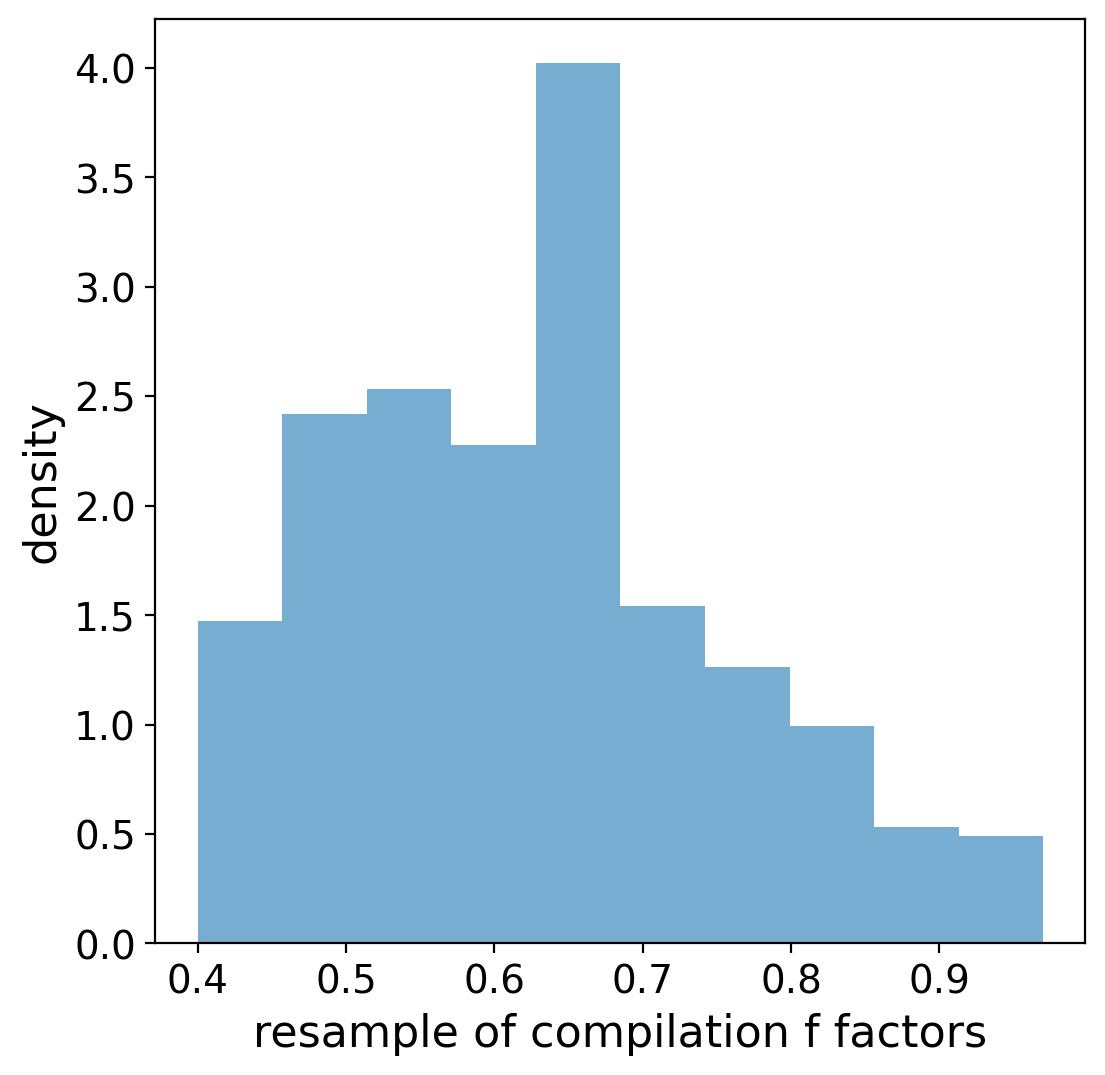

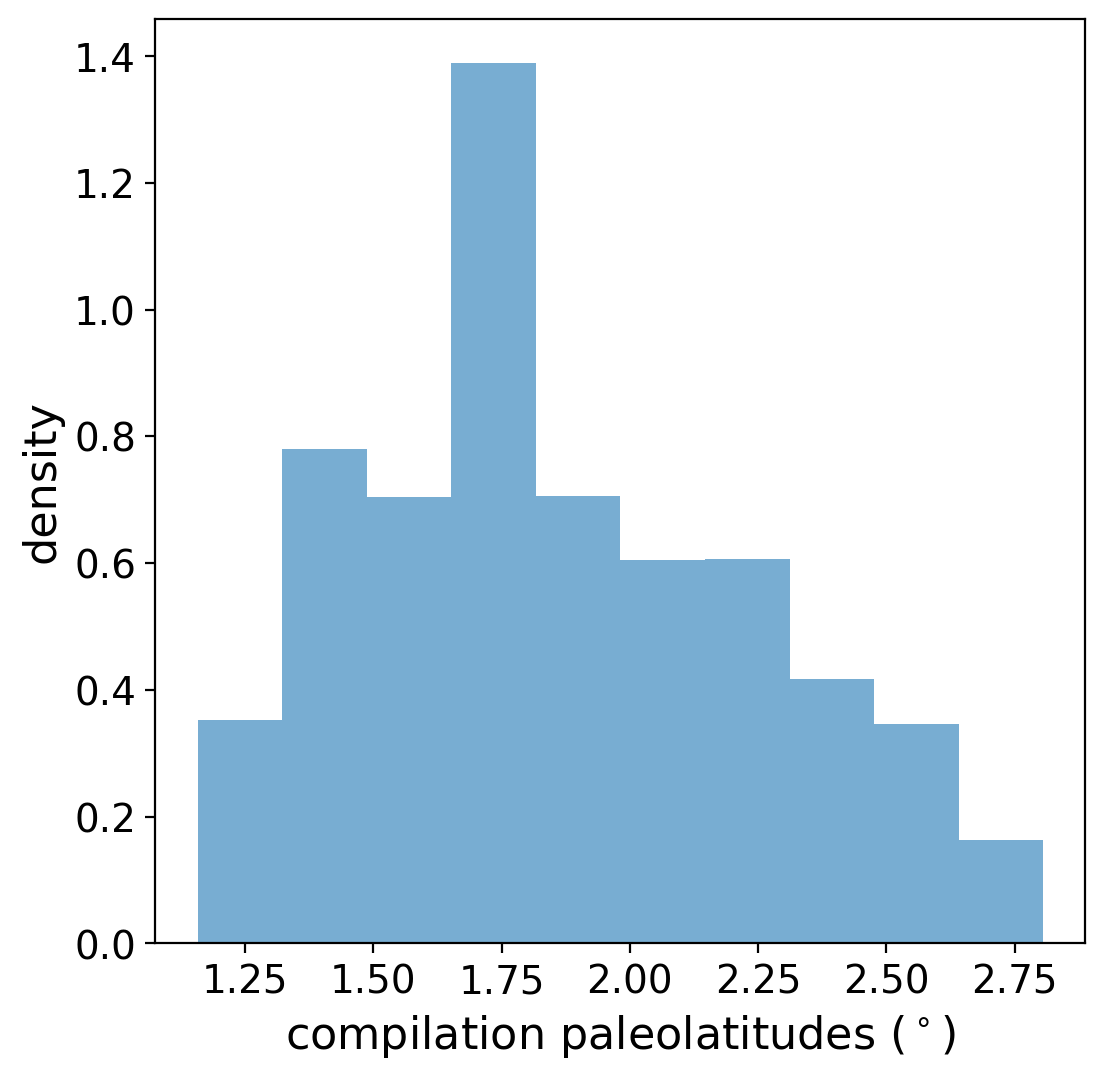

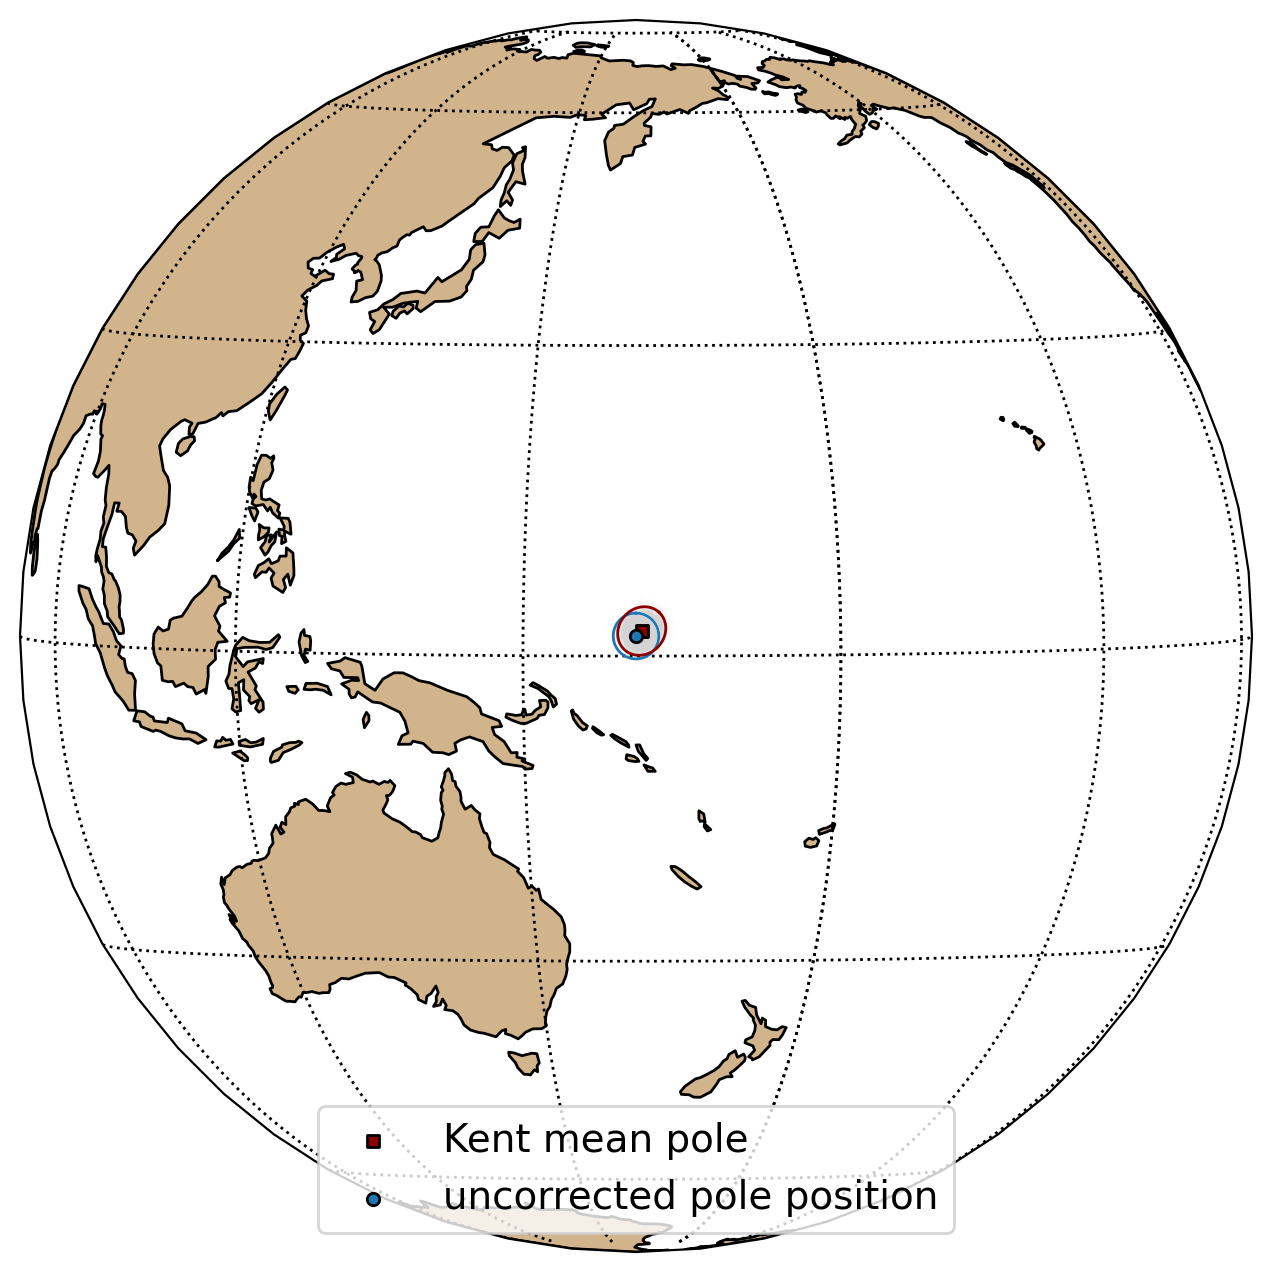

,Terrane,ROCKNAME,Lithology,SLAT,SLONG,nominal age,lomagage,himagage,Grade,f method,...,PLONG,Zdec,Zinc,Zeta,Edec,Einc,Eta,A95,n resampled,Comment
0,Laurentia,Uinta Mountain Group,Sandstone; Mudstone,40.8,250.7,759,743,767,B,"compilation f (Pierce et al., 2022)",...,161.1,253.6,47.1,2.4,68.9,42.8,2.1,2.2,7000,74 site VGPs: too few directions for an E/I or...


In [15]:
# Inclination-shallowing-corrected Kent mean pole (Pierce et al., 2022). The
# random seed is fixed so the exported summary is reproducible.
kent = pt.compilation_kent_pole(site_pole, study_lon, study_lat, random_seed=1)
plt.show()

umg_kent_summary = pt.make_kent_summary(
    umg_summary, kent, 'compilation', 'this study',
    comment='74 site VGPs: too few directions for an E/I or SVEI determination of f')
pt.save_kent_summary(umg_kent_summary, '759_Uinta_Mountain_Group')
umg_kent_summary